In [ ]:
from google.colab import files

uploaded = files.upload()   # select your kaggle.json file here

import os, json, shutil

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "r") as f:
    content = json.load(f)
    print(f"Username : {content['username']}")
    print(f"Key len  : {len(content['key'])}")


Saving kaggle.json to kaggle.json
Username : shrutigavhane475
Key len  : 32


In [ ]:
!kaggle competitions download -c histopathologic-cancer-detection -p ./pcam_raw


100% 6.31G/6.31G [00:43<00:00, 157MB/s]



Extracting labels CSV...
Done!
        FULL DATASET CLASS DISTRIBUTION
  Total samples      : 220,025
  Class 0 (Negative) : 130,908  (59.50%)
  Class 1 (Positive) : 89,117  (40.50%)
  Majority class     : Class 0 (130,908 samples)
  Minority class     : Class 1 (89,117 samples)
  Difference         : 41,791 samples


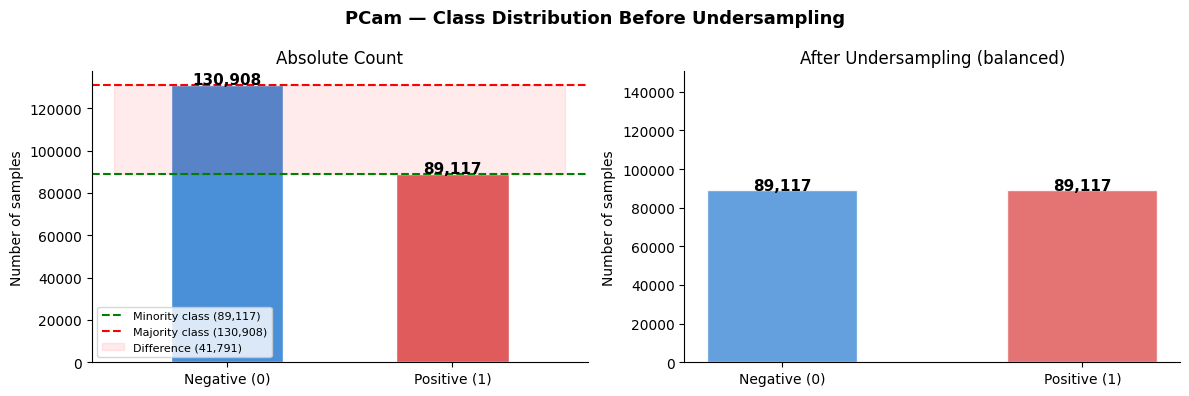

In [ ]:
# ─────────────────────────────────────────────
# Extract Labels & Explore Distribution
# ─────────────────────────────────────────────
from pathlib import Path
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("./pcam_raw")
RAW_ZIP  = DATA_DIR / "histopathologic-cancer-detection.zip"

print("Extracting labels CSV...")
with zipfile.ZipFile(RAW_ZIP, 'r') as z:
    z.extract("train_labels.csv", DATA_DIR)
print("Done!")

df = pd.read_csv(DATA_DIR / "train_labels.csv")
df.columns = ['id', 'label']

counts         = df['label'].value_counts().sort_index()
n_neg          = counts[0]
n_pos          = counts[1]
majority       = counts.max()
minority       = counts.min()
majority_class = counts.idxmax()
minority_class = counts.idxmin()
difference     = majority - minority

print("=" * 50)
print("        FULL DATASET CLASS DISTRIBUTION")
print("=" * 50)
print(f"  Total samples      : {len(df):,}")
print(f"  Class 0 (Negative) : {n_neg:,}  ({n_neg/len(df)*100:.2f}%)")
print(f"  Class 1 (Positive) : {n_pos:,}  ({n_pos/len(df)*100:.2f}%)")
print(f"  Majority class     : Class {majority_class} ({majority:,} samples)")
print(f"  Minority class     : Class {minority_class} ({minority:,} samples)")
print(f"  Difference         : {difference:,} samples")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("PCam — Class Distribution Before Undersampling", fontsize=13, fontweight='bold')
colors = ['#4A90D9', '#E05C5C']

ax1 = axes[0]
bars = ax1.bar(['Negative (0)', 'Positive (1)'], counts.values,
               color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax1.axhline(y=minority, color='green', linestyle='--', linewidth=1.5,
            label=f'Minority class ({minority:,})')
ax1.axhline(y=majority, color='red', linestyle='--', linewidth=1.5,
            label=f'Majority class ({majority:,})')
ax1.fill_between([-0.5, 1.5], minority, majority, alpha=0.08, color='red',
                 label=f'Difference ({difference:,})')
ax1.set_ylabel("Number of samples")
ax1.set_title("Absolute Count")
ax1.legend(fontsize=8)
ax1.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
after_counts = [minority, minority]
bars2 = ax2.bar(['Negative (0)', 'Positive (1)'], after_counts,
                color=colors, width=0.5, edgecolor='white', alpha=0.85)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{minority:,}', ha='center', fontweight='bold', fontsize=11)
ax2.set_ylabel("Number of samples")
ax2.set_title("After Undersampling (balanced)")
ax2.set_ylim(0, majority * 1.15)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches='tight')
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# Undersample & Create Balanced Subset
# ─────────────────────────────────────────────
df_minority = df[df['label'] == minority_class]
df_majority = df[df['label'] == majority_class].sample(n=minority, random_state=42)
df_balanced = pd.concat([df_minority, df_majority]).sample(frac=1, random_state=42).reset_index(drop=True)

print("=" * 50)
print("        AFTER UNDERSAMPLING")
print("=" * 50)
print(f"  Total samples      : {len(df_balanced):,}")
print(f"  Class 0 (Negative) : {(df_balanced['label']==0).sum():,}")
print(f"  Class 1 (Positive) : {(df_balanced['label']==1).sum():,}")
print("=" * 50)

df_balanced.to_csv(DATA_DIR / "balanced_labels.csv", index=False)
print("Balanced labels saved to balanced_labels.csv")


        AFTER UNDERSAMPLING
  Total samples      : 178,234
  Class 0 (Negative) : 89,117
  Class 1 (Positive) : 89,117
Balanced labels saved to balanced_labels.csv


In [ ]:
# ─────────────────────────────────────────────
# Create 20k Subset (10k per class)
# ─────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / "balanced_labels.csv")

SAMPLES_PER_CLASS = 10000

df_subset = df.groupby('label').sample(
    n=SAMPLES_PER_CLASS,
    random_state=42
).sample(frac=1, random_state=42).reset_index(drop=True)

print("="*45)
print(f"  Total   : {len(df_subset):,}")
print(f"  Class 0 : {(df_subset['label']==0).sum():,}")
print(f"  Class 1 : {(df_subset['label']==1).sum():,}")
print("="*45)

df_subset.to_csv(DATA_DIR / "final_subset_labels.csv", index=False)
print("Saved → final_subset_labels.csv")

  Total   : 20,000
  Class 0 : 10,000
  Class 1 : 10,000
Saved → final_subset_labels.csv


In [ ]:

# ─────────────────────────────────────────────
# Extract Images from ZIP
# ─────────────────────────────────────────────
from tqdm import tqdm

TRAIN_DIR = DATA_DIR / "train"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

subset_ids = set(df_subset['id'].values)

print(f"Extracting {len(subset_ids):,} images from ZIP...")
print("This will take 3–5 minutes...")

extracted, skipped = 0, 0

with zipfile.ZipFile(RAW_ZIP, 'r') as z:
    all_files   = z.namelist()
    train_files = [f for f in all_files if f.startswith("train/") and f.endswith(".tif")]

    for fpath in tqdm(train_files, desc="Scanning"):
        fname  = Path(fpath).stem
        if fname in subset_ids:
            target = TRAIN_DIR / f"{fname}.tif"
            if not target.exists():
                z.extract(fpath, DATA_DIR)
                extracted += 1
            else:
                skipped += 1

print(f"\nExtracted : {extracted:,}")
print(f"Skipped   : {skipped:,} (already on disk)")
print(f"Total     : {extracted + skipped:,}")

# Verify
missing = []
for _, row in df_subset.iterrows():
    fp = TRAIN_DIR / f"{row['id']}.tif"
    if not fp.exists():
        missing.append(row['id'])

print("="*45)
print(f"  Found on disk  : {len(df_subset) - len(missing):,}")
print(f"  Missing        : {len(missing)}")
print("  All images verified!" if len(missing) == 0 else f"  WARNING: {len(missing)} missing!")
print("="*45)

Extracting 20,000 images from ZIP...
This will take 3–5 minutes...


Scanning: 100%|██████████| 220025/220025 [00:18<00:00, 11681.72it/s]



Extracted : 20,000
Skipped   : 0 (already on disk)
Total     : 20,000
  Found on disk  : 20,000
  Missing        : 0
  All images verified!


In [ ]:

# ─────────────────────────────────────────────
# Train / Val / Test Split
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split

df_subset['label_str'] = df_subset['label'].astype(str)
df_subset['filepath']  = df_subset['id'].apply(
    lambda x: str(TRAIN_DIR / f"{x}.tif")
)

train_df, temp_df = train_test_split(
    df_subset, test_size=0.30,
    stratify=df_subset['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['label'], random_state=42
)

print("="*45)
print("       DATASET SPLITS")
print("="*45)
print(f"  Train : {len(train_df):,}  (Neg: {(train_df['label']==0).sum():,} | Pos: {(train_df['label']==1).sum():,})")
print(f"  Val   : {len(val_df):,}   (Neg: {(val_df['label']==0).sum():,}  | Pos: {(val_df['label']==1).sum():,})")
print(f"  Test  : {len(test_df):,}   (Neg: {(test_df['label']==0).sum():,}  | Pos: {(test_df['label']==1).sum():,})")
print("="*45)

train_df.to_csv(DATA_DIR / "train_split.csv", index=False)
val_df.to_csv(DATA_DIR  / "val_split.csv",   index=False)
test_df.to_csv(DATA_DIR / "test_split.csv",  index=False)
print("Splits saved!")

       DATASET SPLITS
  Train : 14,000  (Neg: 7,000 | Pos: 7,000)
  Val   : 3,000   (Neg: 1,500  | Pos: 1,500)
  Test  : 3,000   (Neg: 1,500  | Pos: 1,500)
Splits saved!


In [ ]:
# ─────────────────────────────────────────────
# Compute Class Weights  ← BEFORE training
# ─────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [ ]:
# ─────────────────────────────────────────────
#  Data Generators  ← rescale only, NO preprocess_input
# ─────────────────────────────────────────────
# ── TRAIN

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH    = 32

train_datagen = ImageDataGenerator(
    # NO rescale, NO preprocessing_function
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# ── VAL — no rescale
val_datagen = ImageDataGenerator()

# ── TEST — no rescale
test_datagen = ImageDataGenerator()
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_mode='binary', shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_mode='binary', shuffle=False
)
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_mode='binary', shuffle=False
)

print("="*45)
print("DATA GENERATORS")
print("="*45)
print("Train batches :", len(train_gen))
print("Val batches   :", len(val_gen))
print("Test batches  :", len(test_gen))
print("Preprocessing : EfficientNet has built-in normalization")
print("="*45)

Found 14000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.
DATA GENERATORS
Train batches : 438
Val batches   : 94
Test batches  : 94
Preprocessing : EfficientNet has built-in normalization


In [ ]:

# ─────────────────────────────────────────────
# Environment Check
# ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
import time, os

tf.keras.backend.clear_session()

print("="*50)
print("ENVIRONMENT CHECK")
print("="*50)
print("TensorFlow version :", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPU available :", len(gpus) > 0)
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("GPU device :", gpus[0].name)
print("="*50)


ENVIRONMENT CHECK
TensorFlow version : 2.19.0
GPU available : True
GPU device : /physical_device:GPU:0


In [ ]:
# ─────────────────────────────────────────────
# Build EfficientNetB0 (Phase 1 — Feature Extraction)
# ─────────────────────────────────────────────
def build_efficientnet_transfer(input_shape=(224, 224, 3)):
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False   # freeze all backbone layers

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)   # training=False → BN uses stored stats

    # ── Classification Head ──────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs, name="EfficientNetB0_Phase1")
    return model, base_model

efficientnet_model, efficientnet_base = build_efficientnet_transfer()
efficientnet_model.summary()

total     = efficientnet_model.count_params()
trainable = sum([tf.size(w).numpy() for w in efficientnet_model.trainable_weights])
frozen    = total - trainable

print(f"\n  Total parameters     : {total:,}")
print(f"  Trainable parameters : {trainable:,}  ← only the head")
print(f"  Frozen parameters    : {frozen:,}   ← EfficientNet base")



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Phase1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 4,050,083 (15.45 MB)


  Total parameters     : 4,378,788
  Trainable parameters : 328,705  ← only the head
  Frozen parameters    : 4,050,083   ← EfficientNet base


In [ ]:
LEARNING_RATE = 1e-3

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

os.makedirs("./model_checkpoints", exist_ok=True)

def get_callbacks(model_name):
    return [
        callbacks.ModelCheckpoint(
            filepath=f"./model_checkpoints/{model_name}_best.keras",
            monitor='val_auc', mode='max',
            save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_auc', patience=5,
            mode='max', restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-7, verbose=1
        ),
        callbacks.CSVLogger(f"./model_checkpoints/{model_name}_history.csv")
    ]

# ✅ ADD THESE TWO LINES RIGHT HERE — after get_callbacks is defined
phase1_callbacks = get_callbacks("efficientnetb0_phase1")
phase2_callbacks = get_callbacks("efficientnetb0_phase2")

print("Callbacks ready — Phase 1 and Phase 2 use separate checkpoint files!")



Callbacks ready — Phase 1 and Phase 2 use separate checkpoint files!


Pixel value range: 0.0 to 255.0
Expected range   : 0.0 to 255.0


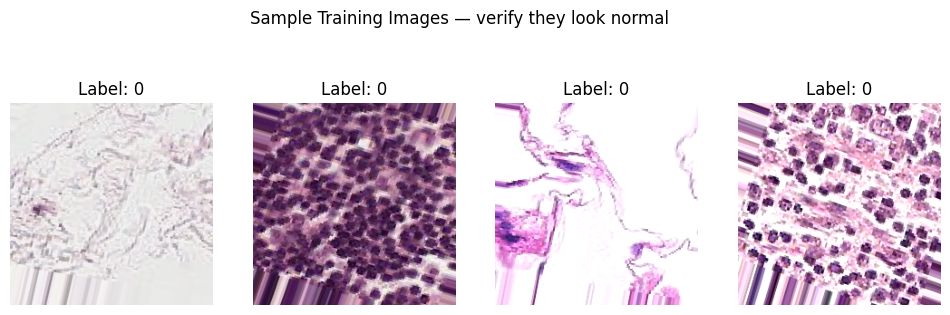

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check a batch
batch_imgs, batch_labels = next(iter(train_gen))

print(f"Pixel value range: {batch_imgs.min():.1f} to {batch_imgs.max():.1f}")
print(f"Expected range   : 0.0 to 255.0")
# If it prints 0.0 to 1.0 → rescaling is wrong, fix generators
# If it prints 0.0 to 255.0 → correct!

plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(batch_imgs[i].astype("uint8"))  # uint8 cast only works if range is 0-255
    plt.title(f"Label: {int(batch_labels[i])}")
    plt.axis('off')
plt.suptitle("Sample Training Images — verify they look normal")
plt.show()

In [ ]:
# ─────────────────────────────────────────────
#  Phase 1: Feature Extraction Training
# ─────────────────────────────────────────────
print("="*50)
print("   TRAINING — EfficientNetB0 (Phase 1: Feature Extraction)")
print("="*50)

start_time = time.time()

efficientnet_history_phase1 = efficientnet_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=phase1_callbacks,
    verbose=1
)

phase1_time = time.time() - start_time
print(f"\nPhase 1 complete! Time: {phase1_time/60:.1f} minutes")


   TRAINING — EfficientNetB0 (Phase 1: Feature Extraction)
Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.7695 - auc: 0.8459 - loss: 0.5140 - precision: 0.7720 - recall: 0.7680
Epoch 1: val_auc improved from None to 0.89957, saving model to ./model_checkpoints/efficientnetb0_phase1_best.keras

Epoch 1: finished saving model to ./model_checkpoints/efficientnetb0_phase1_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 287s 579ms/step - accuracy: 0.7886 - auc: 0.8698 - loss: 0.4647 - precision: 0.7926 - recall: 0.7817 - val_accuracy: 0.8147 - val_auc: 0.8996 - val_loss: 0.4068 - val_precision: 0.8348 - val_recall: 0.7847 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.8102 - auc: 0.8954 - loss: 0.4100 - precision: 0.8199 - recall: 0.8006
Epoch 2: val_auc improved from 0.89957 to 0.91052, saving model to ./model_checkpoints/efficientnetb0_phase1_best.keras

Epoch 2: finished saving model to ./model_checkpoints/efficientnetb0_phase1_be

In [ ]:
# ─────────────────────────────────────────────
# Phase 2: Fine-Tuning (CORRECTED)
# ─────────────────────────────────────────────
print("="*50)
print("   EfficientNetB0 Phase 2 — Fine Tuning")
print("="*50)

# STEP 1 — Load the best Phase 1 model (preserves trained head weights)
efficientnet_model = tf.keras.models.load_model(
    "./model_checkpoints/efficientnetb0_phase1_best.keras"
)
print("✅ Phase 1 best weights loaded — 84% accuracy preserved!")

# STEP 2 — Get reference to base model (it is layer index 1)
base = None
for layer in efficientnet_model.layers:
    if 'efficientnet' in layer.name.lower():
        base = layer
        break

print(f"Base model found: {base.name}")

# STEP 3 — Unfreeze only last 20 layers (not 30)
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

trainable_now = sum([tf.size(w).numpy() for w in efficientnet_model.trainable_weights])
print(f"Trainable parameters now: {trainable_now:,}")

# STEP 4 — Recompile with very low LR (don't rebuild the model!)
efficientnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-6),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print("Recompiled with LR=1e-6")

# STEP 5 — Train Phase 2
start_time = time.time()

efficientnet_history_phase2 = efficientnet_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=phase2_callbacks,    # separate checkpoint
    verbose=1
)

phase2_time = time.time() - start_time
print(f"\nPhase 2 complete! Time: {phase2_time/60:.1f} minutes")

   EfficientNetB0 Phase 2 — Fine Tuning
✅ Phase 1 best weights loaded — 84% accuracy preserved!
Base model found: efficientnetb0
Trainable parameters now: 1,679,665
Recompiled with LR=1e-6
Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.7429 - auc: 0.8229 - loss: 0.5425 - precision: 0.7276 - recall: 0.7788
Epoch 1: val_auc improved from None to 0.81474, saving model to ./model_checkpoints/efficientnetb0_phase2_best.keras

Epoch 1: finished saving model to ./model_checkpoints/efficientnetb0_phase2_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 267s 541ms/step - accuracy: 0.7529 - auc: 0.8328 - loss: 0.5268 - precision: 0.7378 - recall: 0.7844 - val_accuracy: 0.7327 - val_auc: 0.8147 - val_loss: 0.5386 - val_precision: 0.7113 - val_recall: 0.7833 - learning_rate: 1.0000e-06
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.7662 - auc: 0.8523 - loss: 0.4902 - precision: 0.7591 - recall: 0.7851
Epoch 2: val_auc improved from 0.81474 to 0.82278, saving model t

In [ ]:
# After both phases, load whichever checkpoint has better val_auc
phase1_auc = max(efficientnet_history_phase1.history['val_auc'])
phase2_auc = max(efficientnet_history_phase2.history['val_auc'])

best_path = (
    "./model_checkpoints/efficientnetb0_phase1_best.keras"
    if phase1_auc >= phase2_auc else
    "./model_checkpoints/efficientnetb0_phase2_best.keras"
)

print(f"Phase 1 best AUC: {phase1_auc:.4f}")
print(f"Phase 2 best AUC: {phase2_auc:.4f}")
print(f"Loading: {best_path}")

model = tf.keras.models.load_model(best_path)

Phase 1 best AUC: 0.9192
Phase 2 best AUC: 0.8575
Loading: ./model_checkpoints/efficientnetb0_phase1_best.keras


In [ ]:
# ─────────────────────────────────────────────
# — Load Best Model → Evaluate on Test Set
# ─────────────────────────────────────────────
import tensorflow as tf # Ensure tf is imported

# Determine which phase had the best validation AUC
# These history objects are from the previous training cells.
# (efficientnet_history_phase1 and efficientnet_history_phase2 are available in the kernel state)
phase1_auc = max(efficientnet_history_phase1.history['val_auc'])
phase2_auc = max(efficientnet_history_phase2.history['val_auc'])

best_path = (
    "./model_checkpoints/efficientnetb0_phase1_best.keras"
    if phase1_auc >= phase2_auc else
    "./model_checkpoints/efficientnetb0_phase2_best.keras"
)

print(f"Phase 1 best AUC: {phase1_auc:.4f}")
print(f"Phase 2 best AUC: {phase2_auc:.4f}")
print(f"Loading best model from: {best_path}")

# STEP 1: Load best saved model
model = tf.keras.models.load_model(best_path)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print("Best model loaded and re-compiled successfully!")

# STEP 2: Final test evaluation
print("="*50)
print("        FINAL TEST EVALUATION")
print("="*50)
test_results = model.evaluate(test_gen, verbose=1)
metrics_dict = dict(zip(model.metrics_names, test_results))
for k, v in metrics_dict.items():
    print(f"  {k:15s}: {v:.4f}")
print("="*50)

Phase 1 best AUC: 0.9192
Phase 2 best AUC: 0.8575
Loading best model from: ./model_checkpoints/efficientnetb0_phase1_best.keras
Best model loaded and re-compiled successfully!
        FINAL TEST EVALUATION
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.8270 - auc: 0.9133 - loss: 0.3852 - precision: 0.8871 - recall: 0.7493
  loss           : 0.3852
  compile_metrics: 0.8270


94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step


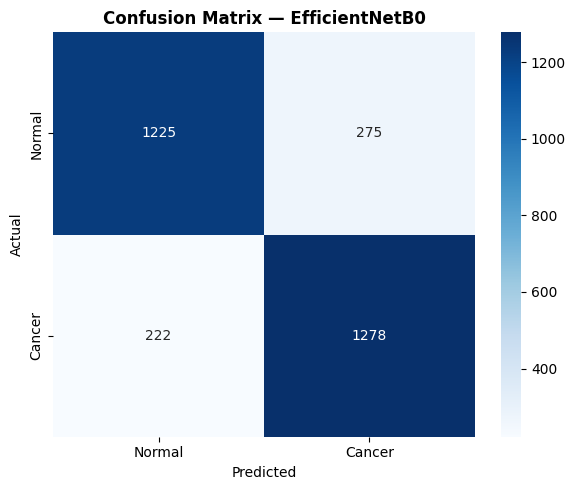

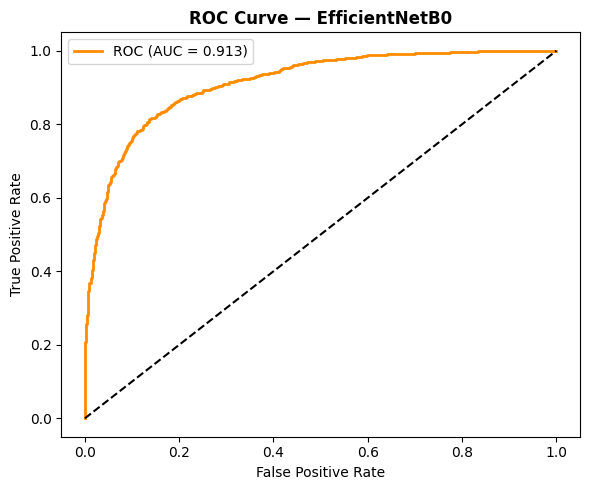

              precision    recall  f1-score   support

      Normal       0.85      0.82      0.83      1500
      Cancer       0.82      0.85      0.84      1500

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



In [ ]:
# ─────────────────────────────────────────────
# Confusion Matrix & ROC Curve
# ─────────────────────────────────────────────
# STEP 3: Predictions AFTER model is loaded
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc as sk_auc
import seaborn as sns

y_pred_prob = model.predict(test_gen)
y_pred      = (y_pred_prob > 0.35).astype(int).flatten()
y_true      = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Cancer'],
            yticklabels=['Normal', 'Cancer'])
plt.title('Confusion Matrix — EfficientNetB0', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc     = sk_auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — EfficientNetB0', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=['Normal', 'Cancer']))


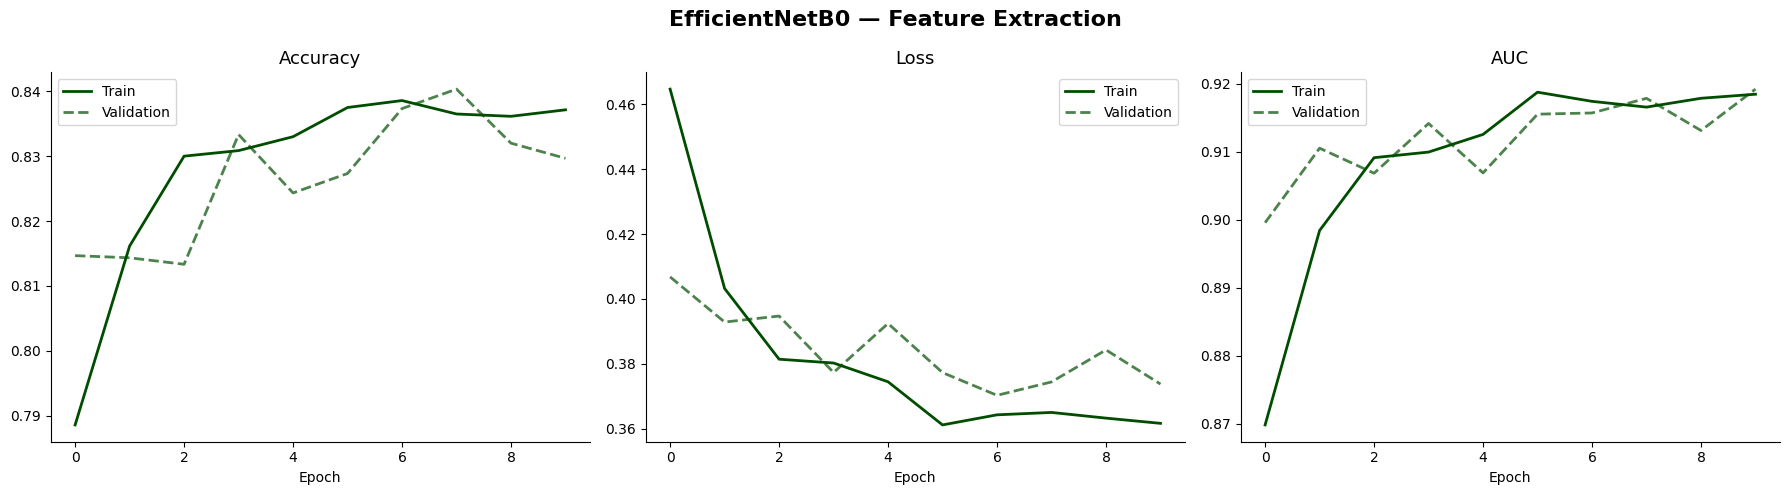

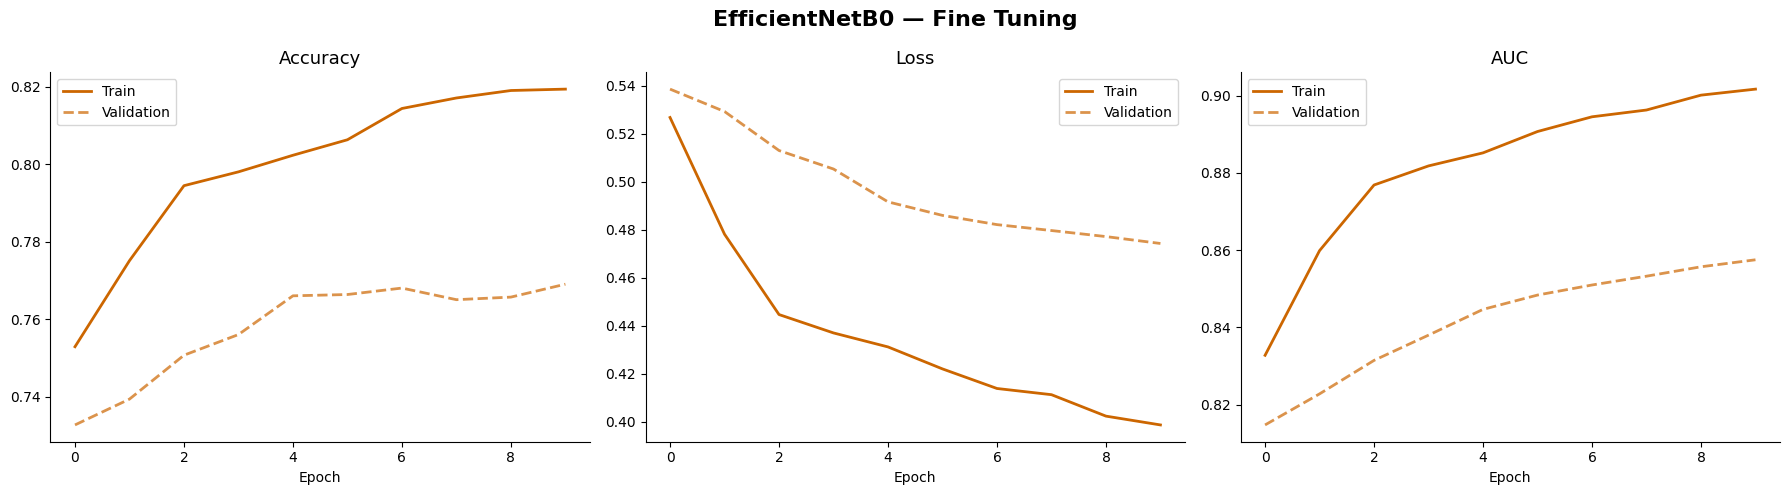

In [ ]:
# ─────────────────────────────────────────────
#  Training Curves
# ─────────────────────────────────────────────
def plot_training_curves(history, title, color):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    metrics      = ['accuracy', 'loss', 'auc']
    display_names = ['Accuracy', 'Loss', 'AUC']

    for i, metric in enumerate(metrics):
        ax = axes[i]
        ax.plot(history.history[metric],          color=color, lw=2, label='Train')
        ax.plot(history.history[f'val_{metric}'], color=color, lw=2,
                linestyle='--', alpha=0.7, label='Validation')
        ax.set_title(display_names[i], fontsize=13)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png")
    plt.show()

plot_training_curves(efficientnet_history_phase1,
                     "EfficientNetB0 — Feature Extraction", '#004d00')
plot_training_curves(efficientnet_history_phase2,
                     "EfficientNetB0 — Fine Tuning",        '#cc6600')



In [ ]:
# ─────────────────────────────────────────────
# Phase Comparison Table
# ─────────────────────────────────────────────
print("\n" + "="*75)
print("        EFFICIENTNETB0 — FINAL PERFORMANCE COMPARISON")
print("="*75)

fe_best = efficientnet_history_phase1.history['val_auc'].index(
    max(efficientnet_history_phase1.history['val_auc'])
)
ft_best = efficientnet_history_phase2.history['val_auc'].index(
    max(efficientnet_history_phase2.history['val_auc'])
)

fe = {k: efficientnet_history_phase1.history[f'val_{k}'][fe_best]
      for k in ['accuracy', 'auc', 'precision', 'recall', 'loss']}
ft = {k: efficientnet_history_phase2.history[f'val_{k}'][ft_best]
      for k in ['accuracy', 'auc', 'precision', 'recall', 'loss']}

print(f"{'Metric':<20} {'Feature Extraction':<25} {'Fine-Tuning':<25}")
print("-"*75)
for key in ['accuracy', 'auc', 'precision', 'recall', 'loss']:
    print(f"  {key.capitalize():<18} {fe[key]:.4f}{'':<15} {ft[key]:.4f}")
print("="*75)
print(f"\n  Best Epoch (Feature Extraction): {fe_best + 1}")
print(f"  Best Epoch (Fine-Tuning)       : {ft_best + 1}")



        EFFICIENTNETB0 — FINAL PERFORMANCE COMPARISON
Metric               Feature Extraction        Fine-Tuning              
---------------------------------------------------------------------------
  Accuracy           0.8297                0.7690
  Auc                0.9192                0.8575
  Precision          0.8854                0.8009
  Recall             0.7573                0.7160
  Loss               0.3738                0.4743

  Best Epoch (Feature Extraction): 10
  Best Epoch (Fine-Tuning)       : 10


Prediction : Normal  |  Confidence : 1.58%


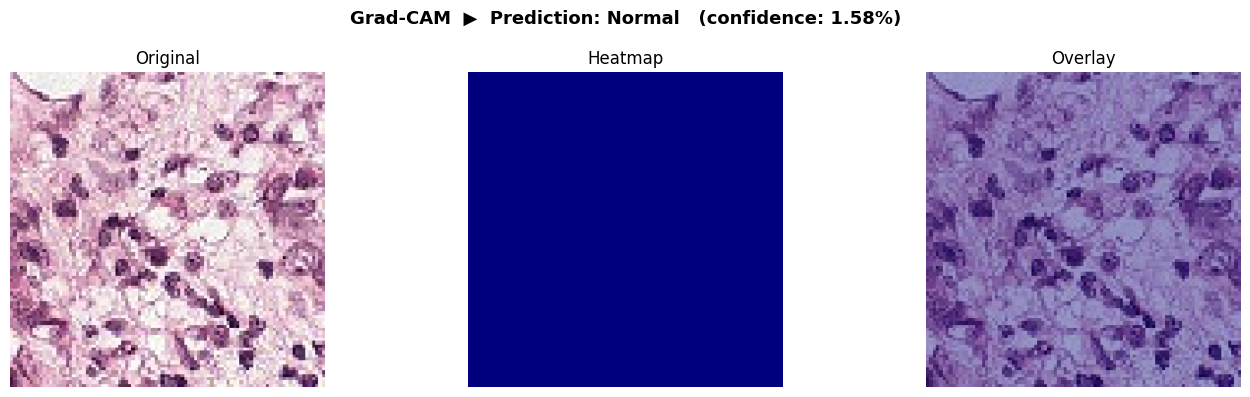

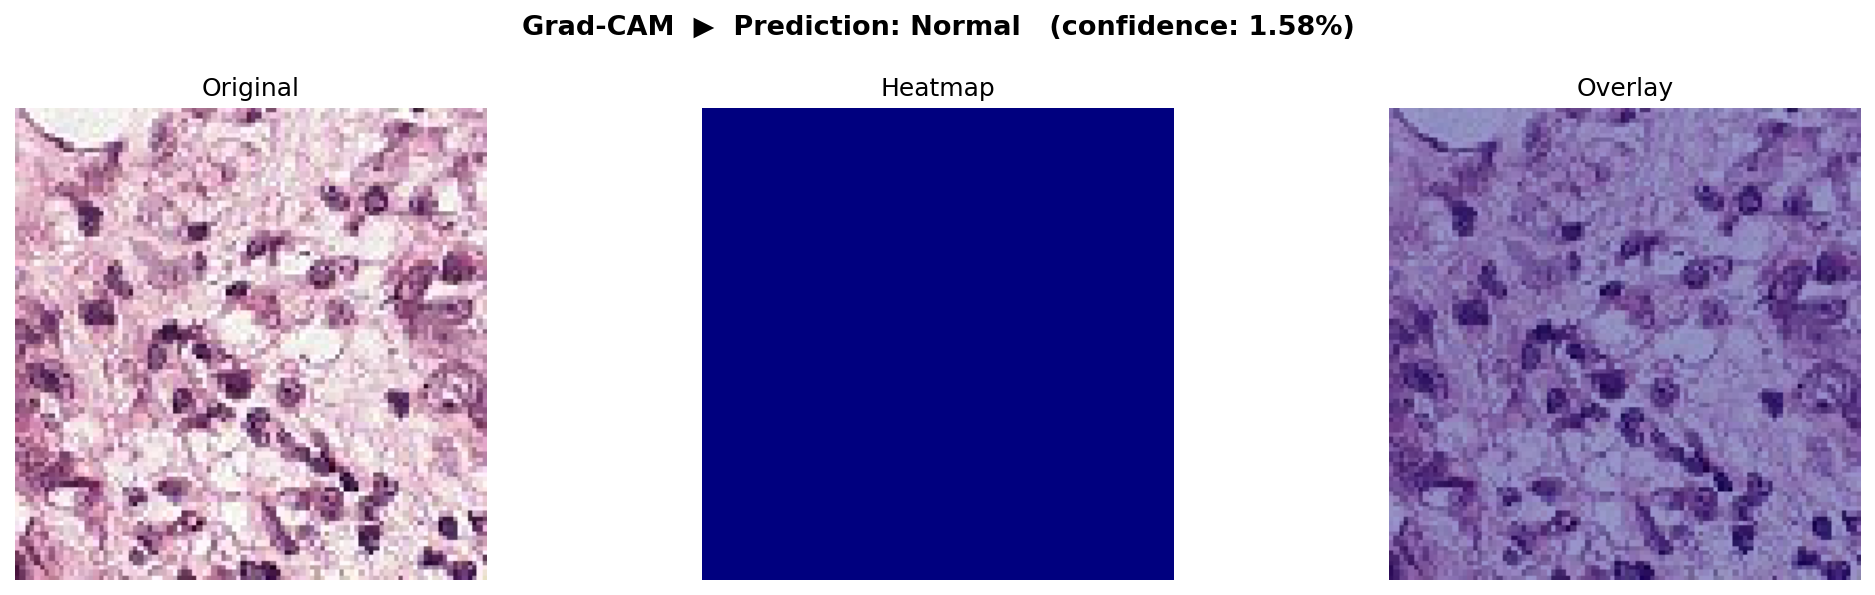

Grad-CAM saved → gradcam_example.png


In [ ]:
def make_gradcam_heatmap(img_array, model):
    efficientnet_base = model.get_layer('efficientnetb0')

    conv_model = tf.keras.models.Model(
        inputs=efficientnet_base.input,
        outputs=efficientnet_base.get_layer("top_conv").output
    )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor, training=False)
        tape.watch(conv_outputs)

        x = conv_outputs
        # Find the index of the efficientnet_base layer in the full model
        base_model_idx = -1
        for i, layer in enumerate(model.layers):
            if layer.name == efficientnet_base.name:
                base_model_idx = i
                break

        if base_model_idx == -1:
            raise ValueError("EfficientNet base layer not found in the model's layers.")

        # Iterate only through the layers *after* the efficientnet_base layer
        # These are the classification head layers.
        for layer in model.layers[base_model_idx + 1:]:
            try:
                # Pass training=False for consistent prediction behavior
                x = layer(x, training=False)
            except TypeError:
                # Some layers (e.g., GlobalAveragePooling2D, simple Dense) might not accept 'training' arg
                x = layer(x)
            except Exception as e:
                print(f"Error applying layer {layer.name}: {e}")
                raise

        predictions = x
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        raise ValueError("Gradients are None.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def display_gradcam(img_path, model, alpha=0.4):
    """Load image, compute Grad-CAM, overlay and display."""
    import cv2
    import numpy as np
    from IPython.display import Image as IPImage, display as ipy_display

    # ── Load & preprocess ──
    img     = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0   # (224,224,3) float
    img_input = np.expand_dims(img_arr, axis=0)                         # (1,224,224,3)

    # ── Predict ──
    pred  = model.predict(img_input, verbose=0)[0][0]
    label = "Cancer" if pred > 0.5 else "Normal"
    print(f"Prediction : {label}  |  Confidence : {pred:.2%}")

    # ── Grad-CAM ──
    heatmap   = make_gradcam_heatmap(img_input, model)

    # ── Resize & colorize heatmap ──
    heatmap_r = cv2.resize(heatmap, (224, 224))
    heatmap_u = np.uint8(255 * heatmap_r)
    heatmap_c = cv2.applyColorMap(heatmap_u, cv2.COLORMAP_JET)
    heatmap_c = cv2.cvtColor(heatmap_c, cv2.COLOR_BGR2RGB) / 255.0     # (224,224,3) float

    # ── Blend ──
    overlay = np.clip((1 - alpha) * img_arr + alpha * heatmap_c, 0, 1)

    # ── Plot ──
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        f"Grad-CAM  ▶  Prediction: {label}   (confidence: {pred:.2%})",
        fontsize=13, fontweight='bold'
    )
    axes[0].imshow(img_arr);                    axes[0].set_title("Original");  axes[0].axis('off')
    axes[1].imshow(heatmap_r, cmap='jet');      axes[1].set_title("Heatmap");   axes[1].axis('off')
    axes[2].imshow(overlay);                    axes[2].set_title("Overlay");   axes[2].axis('off')

    plt.tight_layout()
    save_path = "gradcam_example.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # ── Colab fallback display ──
    ipy_display(IPImage(filename=save_path))
    return save_path


# ── Run ──
sample_row = test_df.iloc[0]
display_gradcam(sample_row['filepath'], model)
print("Grad-CAM saved → gradcam_example.png")